# Exploratory Data Analysis

#### Importing Directory and Loading Data

In [2]:
import pandas as pd

fact_orders = pd.read_csv("../data/raw/fact_orders.csv")
fact_inventory = pd.read_csv("../data/raw/fact_inventory.csv")
dim_products = pd.read_csv("../data/raw/dim_products.csv")
dim_customers = pd.read_csv("../data/raw/dim_customers.csv")
dim_stores = pd.read_csv("../data/raw/dim_stores.csv")
dim_date = pd.read_csv("../data/raw/dim_date.csv")

##### A dictionary containing all tables was created to simplify repetitive exploratory analysis tasks across multiple datasets. The shape of each dataset was inspected to understand the number of rows and columns available in each table.

In [3]:
tables = {
    "fact_orders": fact_orders,
    "fact_inventory": fact_inventory,
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_stores": dim_stores,
    "dim_date": dim_date
}

for name, table in tables.items():
    print(f"{name}: {table.shape}")

fact_orders: (20001, 12)
fact_inventory: (4999, 8)
dim_products: (250, 7)
dim_customers: (2501, 6)
dim_stores: (15, 6)
dim_date: (731, 7)


##### The first few records of the datasets were reviewed using .head() to understand:

- column structure
- data formatting
- business entities
- transactional flow

In [4]:
fact_orders.head(2)

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method
0,ORD000001,2025-09-01,16:25:00,CUST02281,PROD0100,STR009,Online,4,35910.88,15,122096.99,Card
1,ORD000002,2025-08-23,11:04:00,CUST01960,PROD0070,STR002,Offline,5,15345.24,0,76726.20,UPI


In [5]:
fact_inventory.head(2)

,inventory_id,product_id,store_id,stock_received,stock_sold,current_stock,reorder_level,inventory_date
0,INV00001,PROD0016,STR010,280,4,301,22.0,2024-07-04
1,INV00002,PROD0090,STR009,59,112,310,52.0,2024-08-11


In [6]:
dim_products.head(2)

,product_id,product_name,category,sub_category,brand,cost_price,selling_price
0,PROD0001,Prestige Furniture 1,Home & Kitchen,Furniture,Prestige,23858.26,35154.87
1,PROD0002,Dell Mobiles 2,Electronics,Mobiles,Dell,21238.80,44634.91


In [7]:
dim_customers.head(2)

,customer_id,customer_name,city,state,loyalty_status,signup_date
0,CUST00001,Priya Gupta,Mumbai,Maharashtra,Silver,2022-05-24
1,CUST00002,Aarav Verma,Patna,Bihar,Regular,2021-11-08


In [8]:
dim_stores.head(2)

,store_id,store_name,city,state,region,store_type
0,STR001,Delhi Retail Hub,Delhi,Delhi,North,Standalone
1,STR002,Mumbai Retail Hub,Mumbai,Maharashtra,West,Mall


In [9]:
dim_date.head(2)

,full_date,year,quarter,month,month_number,day_name,is_weekend
0,2024-01-01,2024,Q1,January,1,Monday,No
1,2024-01-02,2024,Q1,January,1,Tuesday,No


##### Duplicate Record Inspection

In [10]:
for name, table in tables.items():
    print(f"{name}: {table.duplicated().sum()} duplicate rows")

fact_orders: 1 duplicate rows
fact_inventory: 0 duplicate rows
dim_products: 0 duplicate rows
dim_customers: 1 duplicate rows
dim_stores: 0 duplicate rows
dim_date: 0 duplicate rows


> The duplicate rows in both fact_orders and dim_customers were inspected before removal to confirm whether they were true duplicates or valid repeated records.

In [11]:
dim_customers[dim_customers.duplicated()]

,customer_id,customer_name,city,state,loyalty_status,signup_date
2500,CUST00001,Priya Gupta,Mumbai,Maharashtra,Silver,2022-05-24


> Both tables contained true duplicate records with identical values across all columns.

##### Duplicate records were removed to maintain accurate

In [12]:
fact_orders = fact_orders.drop_duplicates()

dim_customers = dim_customers.drop_duplicates()

##### The tables dictionary was then refreshed to ensure the updated cleaned datasets were referenced.

In [13]:
tables = {
    "fact_orders": fact_orders,
    "fact_inventory": fact_inventory,
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_stores": dim_stores,
    "dim_date": dim_date
}

##### Verification was performed to confirm successful duplicate removal.

In [14]:
for name, table in tables.items():
    print(f"{name}: {table.duplicated().sum()} duplicate rows")

fact_orders: 0 duplicate rows
fact_inventory: 0 duplicate rows
dim_products: 0 duplicate rows
dim_customers: 0 duplicate rows
dim_stores: 0 duplicate rows
dim_date: 0 duplicate rows


> All datasets now contain zero duplicate rows, improving the reliability and consistency of further business analysis and dashboard reporting.

##### The `order_date` column in the `fact_orders` table was stored as a string datatype. Since retail sales analysis heavily depends on time-based trends and seasonality, the column required conversion into a proper datetime format.

> Checking the order_date current format

In [15]:
fact_orders[['order_date', 'order_time']].head(10)

,order_date,order_time
0,2025-09-01,16:25:00
1,2025-08-23,11:04:00
2,2024-12-01,22:25:00
3,2025-11-23,14:48:00
4,2024-05-18,13:20:00
5,2024-12-05,22:11:00
6,2024-11-02,16:29:00
7,2025-02-11,22:41:00
8,2024-06-25,09:38:00
9,2024-05-14,14:17:00


##### Converting order_date column into datetime datatype using Pandas.

In [16]:
fact_orders['order_date'] = pd.to_datetime(
    fact_orders['order_date'],
    errors='coerce'
)

> The errors='coerce' parameter ensures that any invalid or corrupted date values are automatically converted into NaT (Not a Time) instead of generating execution errors.

##### Verifying the Data type of order_date

In [17]:
fact_orders['order_date'].dtype

dtype('<M8[us]')

> order_date column is now properly converted.

##### Checking if Any Invalid Dates Became NaT

In [18]:
fact_orders['order_date'].isnull().sum()

np.int64(1)

> During conversion 1 value became NaT

In [19]:
fact_orders[fact_orders['order_date'].isnull()]

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method
150,ORD000151,NaT,10:20:00,CUST02325,PROD0181,STR006,Offline,4,36967.04,15,125687.94,Card


##### Remove Invalid Date Rows

In [20]:
fact_orders = fact_orders.dropna(subset=['order_date'])

##### Verifying the null or NaT values

In [21]:
fact_orders['order_date'].isnull().sum()

np.int64(0)

> Observation:
One transactional record contained an invalid order_date value which was converted to NaT during datetime parsing. Since transaction dates are critical for time-series and seasonal analysis, the record was removed to maintain analytical accuracy.

##### Convert order_time to time data type, initially it was str fromat

In [22]:
fact_orders['order_time'] = pd.to_datetime(
    fact_orders['order_time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.time

In [23]:
fact_orders['order_time'].isnull().sum()

np.int64(0)

##### Missing Values Analysis

In [24]:
for name, table in tables.items():
    print(f"\n{name.upper()}")

    missing = table.isnull().sum()

    missing = missing[missing > 0]

    print(missing)


FACT_ORDERS
order_date    1
unit_price    1
dtype: int64

FACT_INVENTORY
reorder_level    1
dtype: int64

DIM_PRODUCTS
product_name     1
selling_price    1
dtype: int64

DIM_CUSTOMERS
customer_name    1
dtype: int64

DIM_STORES
state    1
dtype: int64

DIM_DATE
Series([], dtype: int64)


##### Inspecting Missing Values in fact_orders

In [25]:
fact_orders[fact_orders['unit_price'].isnull()]

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method
70,ORD000071,2024-04-23,11:33:00,CUST01056,PROD0075,STR009,Online,5,NaN,0,195676.5,UPI


> The `unit_price` column contained a missing value in the `fact_orders` table.

> Instead of using statistical imputation methods such as mean or median, the missing value was derived using existing transactional business logic.

In [26]:
fact_orders['unit_price'] = fact_orders['unit_price'].fillna(
    fact_orders['sales_amount'] / fact_orders['quantity']
)

In [27]:
fact_orders['unit_price'].isnull().sum()

np.int64(0)

##### Inspecting Missing Values in fact_inventory

In [28]:
fact_inventory[fact_inventory['reorder_level'].isnull()]

,inventory_id,product_id,store_id,stock_received,stock_sold,current_stock,reorder_level,inventory_date
40,INV00041,PROD0081,STR007,44,195,367,NaN,2024-03-16


##### Handling Missing reorder_level Values

In [29]:
fact_inventory['reorder_level'] = fact_inventory['reorder_level'].fillna(
    fact_inventory['reorder_level'].median()
)

##### Verifying

> Since the value could not be directly derived from existing columns, median imputation was selected to preserve realistic inventory behavior while minimizing the effect of extreme values or outliers.

In [30]:
fact_inventory['reorder_level'].isnull().sum()

np.int64(0)

##### Handling Missing product_name in dim_products

> Inspecting Missing Values in dim_products

In [31]:
dim_products[dim_products['product_name'].isnull()]

,product_id,product_name,category,sub_category,brand,cost_price,selling_price
30,PROD0031,NaN,Beauty,Skincare,Lakme,20965.51,39654.3


In [32]:
dim_products['product_name'] = dim_products['product_name'].fillna(
    'Unknown Product'
)

> To preserve transactional consistency while maintaining data integrity, the missing value was replaced with the placeholder value `Unknown Product`.

In [33]:
dim_products['product_name'].isnull().sum()

np.int64(0)

##### Inspecting Missing selling_price Values in dim_products

In [34]:
dim_products[dim_products['selling_price'].isnull()]

,product_id,product_name,category,sub_category,brand,cost_price,selling_price
20,PROD0021,Puma Footwear 21,Fashion,Footwear,Puma,4840.02,NaN


##### Handling Missing selling_price Values in dim_products

> Instead of using a global average, the missing selling price was filled using the median selling price of products within the same sub_category (`Footwear`).

In [35]:
footwear_median = dim_products[
    dim_products['sub_category'] == 'Footwear'
]['selling_price'].median()

dim_products['selling_price'] = dim_products['selling_price'].fillna(
    footwear_median
)


In [36]:
dim_products['selling_price'].isnull().sum()

np.int64(0)

##### Handling Missing customer_name in dim_customers

> Inspecting Missing customer_name Values in dim_customers

In [37]:
dim_customers[dim_customers['customer_name'].isnull()]

,customer_id,customer_name,city,state,loyalty_status,signup_date
10,CUST00011,NaN,Jaipur,Rajasthan,Gold,2022-05-21


> Since customer identity information could not be reliably inferred from other attributes, the missing value was replaced using the placeholder value `Unknown Customer`.

In [38]:
dim_customers['customer_name'] = dim_customers['customer_name'].fillna(
    'Unknown Customer'
)

In [39]:
dim_customers['customer_name'].isnull().sum()

np.int64(0)

##### Inspecting Missing state Values in dim_stores

In [40]:
dim_stores[dim_stores['state'].isnull()]

,store_id,store_name,city,state,region,store_type
7,STR008,Jaipur Retail Hub,Jaipur,NaN,North,Mall


##### Handling Missing state Values in dim_stores


> Since the store city was identified as `Jaipur`, the corresponding state could be logically inferred as `Rajasthan`.

In [41]:
dim_stores.loc[
    dim_stores['state'].isnull(),
    'state'
] = 'Rajasthan'

##### Refreshing the table dictionary.

In [42]:
tables = {
    "fact_orders": fact_orders,
    "fact_inventory": fact_inventory,
    "dim_products": dim_products,
    "dim_customers": dim_customers,
    "dim_stores": dim_stores,
    "dim_date": dim_date
}

##### Verifying the missing values in all the tables

In [43]:
for name, table in tables.items():
    print(f"\n{name.upper()}")

    missing = table.isnull().sum()

    missing = missing[missing > 0]

    print(missing)


FACT_ORDERS
Series([], dtype: int64)

FACT_INVENTORY
Series([], dtype: int64)

DIM_PRODUCTS
Series([], dtype: int64)

DIM_CUSTOMERS
Series([], dtype: int64)

DIM_STORES
Series([], dtype: int64)

DIM_DATE
Series([], dtype: int64)


##### Business KPI Validation - Sales Metrics

> The following analysis validates the foundational revenue metrics from the transactional dataset.
> - Total Sales analysis
> - Average Revenue per Order
> - Sales trend monitoring

> These metrics are essential for:
> - store performance tracking
> - executive reporting
> - revenue monitoring
> - business decision-making

In [44]:
total_sales = fact_orders['sales_amount'].sum()

avg_order_value = fact_orders['sales_amount'].mean()

print(f"Total Sales: {total_sales:,.2f}")

print(f"Average Revenue per Order: {avg_order_value:,.2f}")

Total Sales: 1,316,480,624.87
Average Revenue per Order: 65,827.32


##### Monthly Sales Output

In [45]:
monthly_sales = fact_orders.groupby(
    fact_orders['order_date'].dt.month
)['sales_amount'].sum().sort_index()

monthly_sales = monthly_sales.round(2)

monthly_sales.apply(lambda x: f"{x:,.2f}")

order_date
1      92,034,112.64
2      78,384,603.68
3      91,725,702.53
4      82,987,718.88
5      89,221,810.14
6      90,543,430.50
7      83,870,821.66
8      95,647,696.13
9      84,858,564.40
10    175,509,989.93
11    175,885,975.08
12    175,810,199.30
Name: sales_amount, dtype: str

##### Monthly Sales Trend Visualization

>This analysis helps identify:
- seasonal demand patterns
- high-performing revenue periods
- low-sales months
- Q4 holiday demand spikes

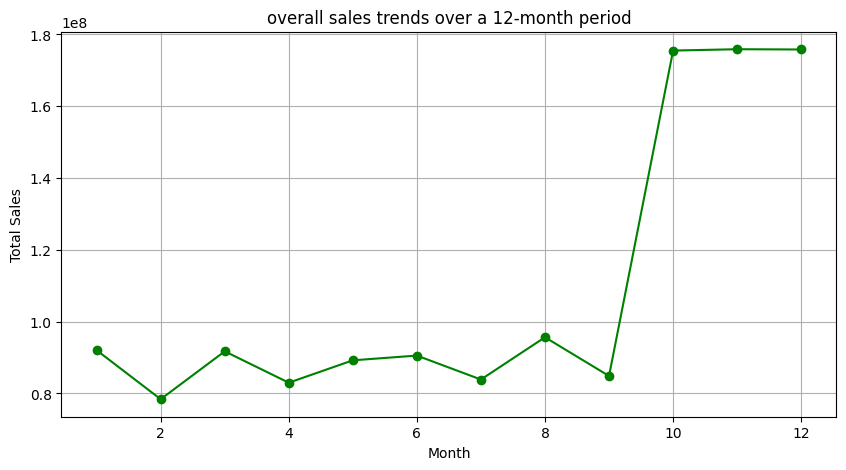

In [46]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    color='green'
)

plt.title('overall sales trends over a 12-month period')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

### Product Category Performance Analysis
> Identifying the best-performing product categories, to perform this analysis, the transactional sales dataset must be combined with the product master dataset using the common `product_id` field.

In [47]:
orders_products = fact_orders.merge(
    dim_products,
    on='product_id',
    how='left'
)

orders_products.head(3)

,order_id,order_date,order_time,customer_id,product_id,store_id,sales_channel,quantity,unit_price,discount_pct,sales_amount,payment_method,product_name,category,sub_category,brand,cost_price,selling_price
0,ORD000001,2025-09-01,16:25:00,CUST02281,PROD0100,STR009,Online,4,35910.88,15,122096.99,Card,Lakme Makeup 100,Beauty,Makeup,Lakme,26163.54,35910.88
1,ORD000002,2025-08-23,11:04:00,CUST01960,PROD0070,STR002,Offline,5,15345.24,0,76726.20,UPI,Decathlon Outdoor 70,Sports,Outdoor,Decathlon,8749.83,15345.24
2,ORD000003,2024-12-01,22:25:00,CUST02026,PROD0248,STR001,Offline,3,6525.56,10,17619.01,Card,Philips Furniture 248,Home & Kitchen,Furniture,Philips,3329.39,6525.56


#### Product Category Revenue Analysis

> The following analysis aggregates total sales revenue by product category using the merged transactional and product datasets.

In [52]:
category_sales = orders_products.groupby(
    'category'
)['sales_amount'].sum().sort_values(ascending=False)

category_sales.apply(lambda x: f"{x:,.2f}")

category
Beauty            330,668,705.19
Fashion           300,797,705.58
Electronics       249,021,166.70
Home & Kitchen    221,342,137.29
Sports            214,650,910.11
Name: sales_amount, dtype: str

#### Category Standardization
> inconsistent categorical values were identified within the `category` column.

For example:
- `Electronics`
- `electronics`

In [50]:
orders_products['category'] = orders_products['category'].str.strip().str.title()

#str.strip removes spaces while str.title makes standardization from electronics to Electronics

In [51]:
# Checking Categories after standardization
orders_products['category'].unique()

<StringArray>
['Beauty', 'Sports', 'Home & Kitchen', 'Electronics', 'Fashion']
Length: 5, dtype: str

#### Product Category Revenue Visualization

> this visualization compare total revenue contribution across different product categories.

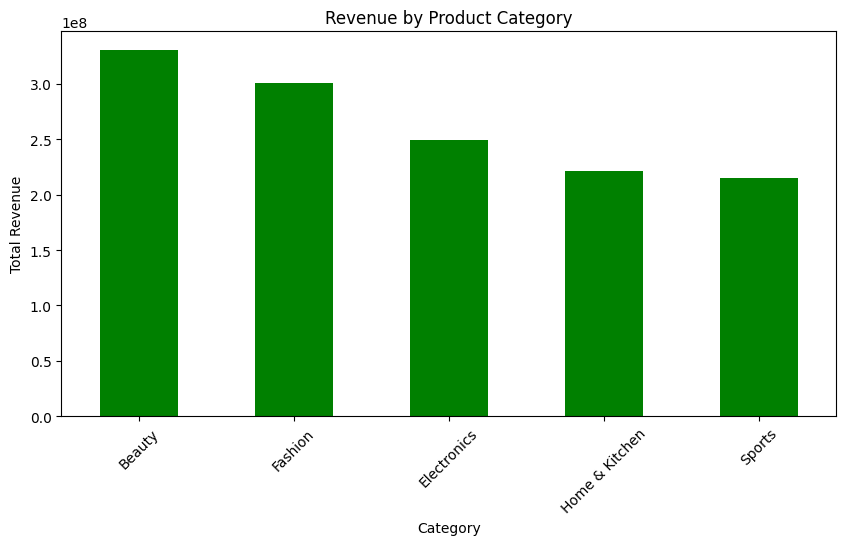

In [54]:
import matplotlib.pyplot as plt

category_sales.plot(
    kind='bar',
    figsize=(10,5),
    color = 'green'
)

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

#### Peak Purchasing Hour Analysis
> following step extracts the hourly component from transaction timestamps for time-based sales analysis.

In [55]:
fact_orders['order_hour'] = pd.to_datetime(
    fact_orders['order_time'],
    format='%H:%M:%S'
).dt.hour

fact_orders[['order_time', 'order_hour']].head()

,order_time,order_hour
0,16:25:00,16
1,11:04:00,11
2,22:25:00,22
3,14:48:00,14
4,13:20:00,13


#### Hourly Sales Performance Analysis
> The following analysis aggregates total sales revenue at the hourly level.

In [56]:
hourly_sales = fact_orders.groupby(
    'order_hour'
)['sales_amount'].sum().sort_values(ascending=False)

hourly_sales.apply(lambda x: f"{x:,.2f}")

order_hour
16    91,703,417.30
15    90,898,077.57
22    90,813,820.14
17    90,213,126.84
19    88,947,450.19
9     88,465,574.49
11    88,427,631.82
8     88,282,036.60
20    87,058,280.03
10    86,937,655.49
18    86,165,035.98
13    85,275,031.01
12    85,068,937.46
21    85,054,083.59
14    83,170,466.36
Name: sales_amount, dtype: str

#### Peak Purchasing Hour Visualization
> visualization highlights hourly revenue distribution and peak purchasing behavior patterns.

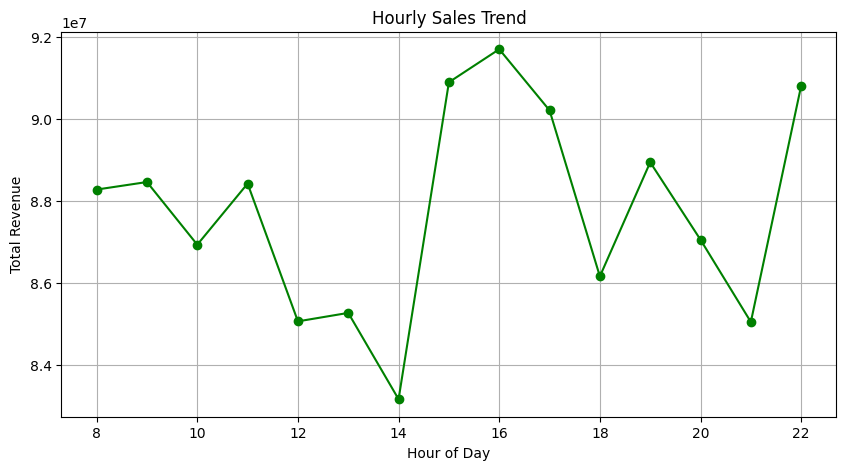

In [62]:
hourly_sales.sort_index().plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    color='green'
)

plt.title('Hourly Sales Trend')
plt.xlabel('Hour of Day')
plt.ylabel('Total Revenue')

plt.grid(True)

plt.show()